<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_7_MLR_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Toyota Corolla Price Prediction using Multiple Linear Regression
1. Objective

The objective of this analysis is to build a Multiple Linear Regression (MLR) model to predict the price of Toyota Corolla cars based on various attributes such as age, kilometers driven, horsepower, fuel type, weight, and other car specifications.

The workflow includes:

Exploratory Data Analysis (EDA)

Data preprocessing

Multicollinearity detection using VIF

Feature selection

Building multiple regression models

Evaluating models using performance metrics

Applying Ridge and Lasso regularization to evaluate model stability and compare predictive performance.



###Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import f_regression, SelectKBest

##Load Dataset

In [ ]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.shape

(1436, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated(keep=False)]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
112,24950,8,13253,Diesel,116,0,2000,5,4,5,1320
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.shape

(1436, 11)

Remove Duplicate and Constant Columns

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1435, 11)

After removing duplicates, the dataset contains 1435 rows and 11 columns.

To examine the number of unique values in each column.

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Price: 236
Age_08_04: 77
KM: 1263
Fuel_Type: 3
HP: 12
Automatic: 2
cc: 13
Doors: 4
Cylinders: 1
Gears: 4
Weight: 59


 Constant Column Removal

 The column Cylinders contained only one unique value and therefore had no variance, making it uninformative for regression. Hence, it was removed from the dataset.

In [ ]:
df.drop(columns=['Cylinders'], inplace=True)

In [ ]:
df.shape # show that 'Cylinders' column removed

(1435, 10)

#Exploratory Data Analysis (EDA)

##1.Histograms

Purpose:

Understand distribution

Identify skewness and outliers.

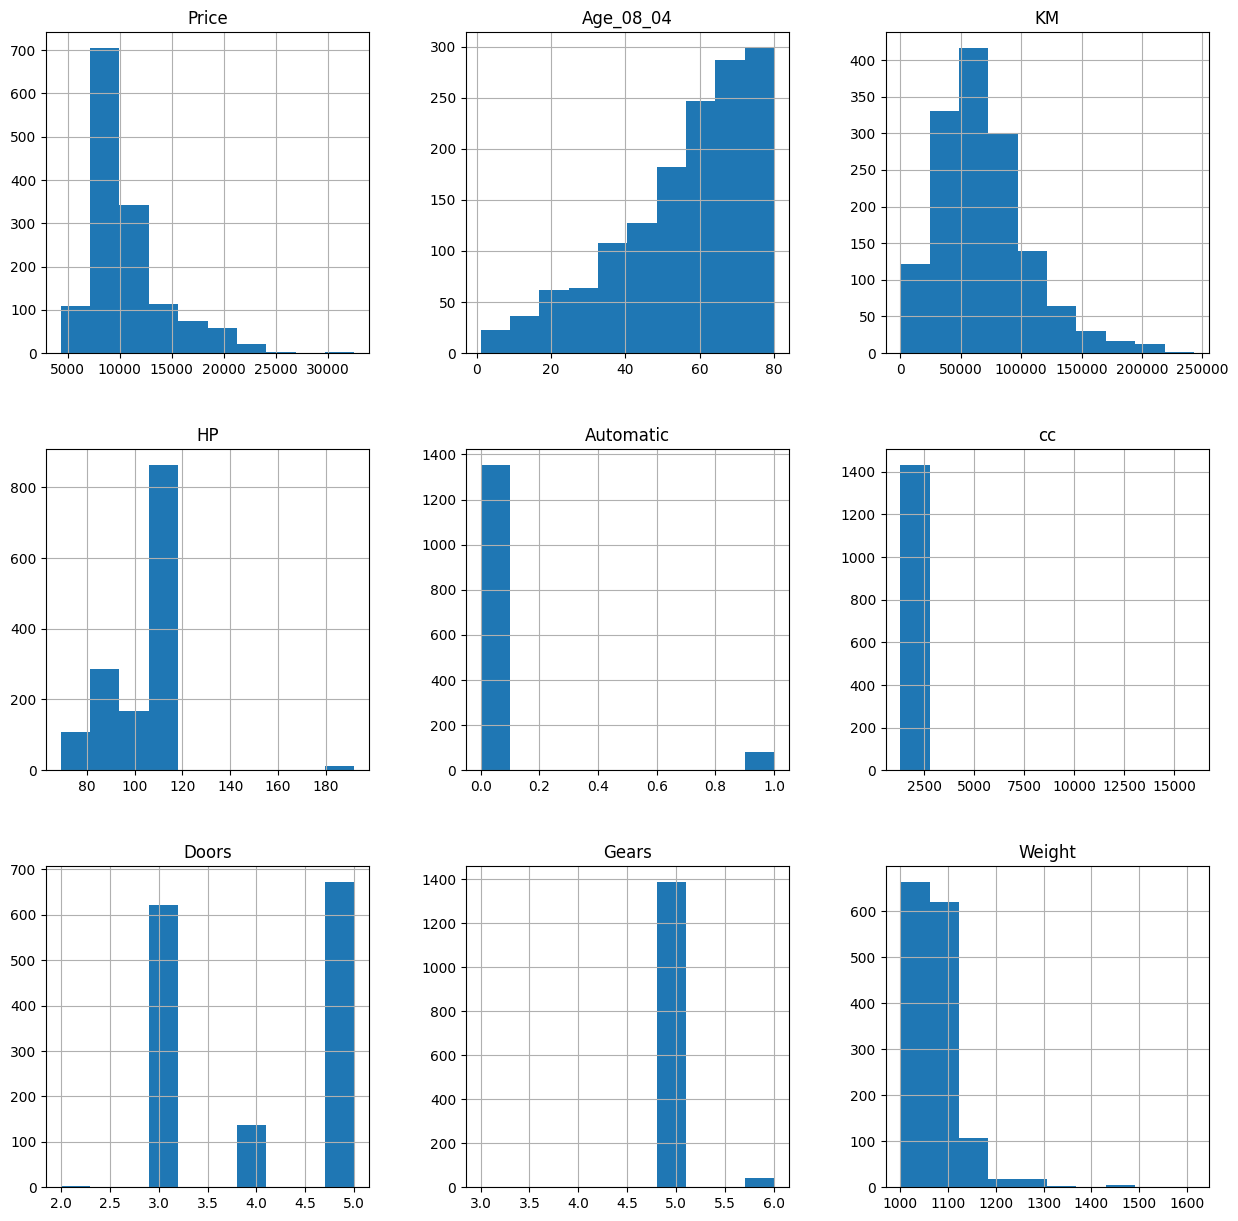

In [ ]:
df.hist(figsize=(15,15))
plt.show()

Distribution Analysis

Histograms were used to analyze the distribution of numerical variables such as:

•	Price

•	Age

•	Kilometers

•	Horsepower

•	Weight

Observations:

Price and KM show positive skewness, indicating that most observations are concentrated at lower values with a smaller number of higher extreme values.

Age is approximately normally distributed


##2.Correlation Heatmap
Important insights:

Age → negatively correlated with Price

Weight → positively correlated with Price

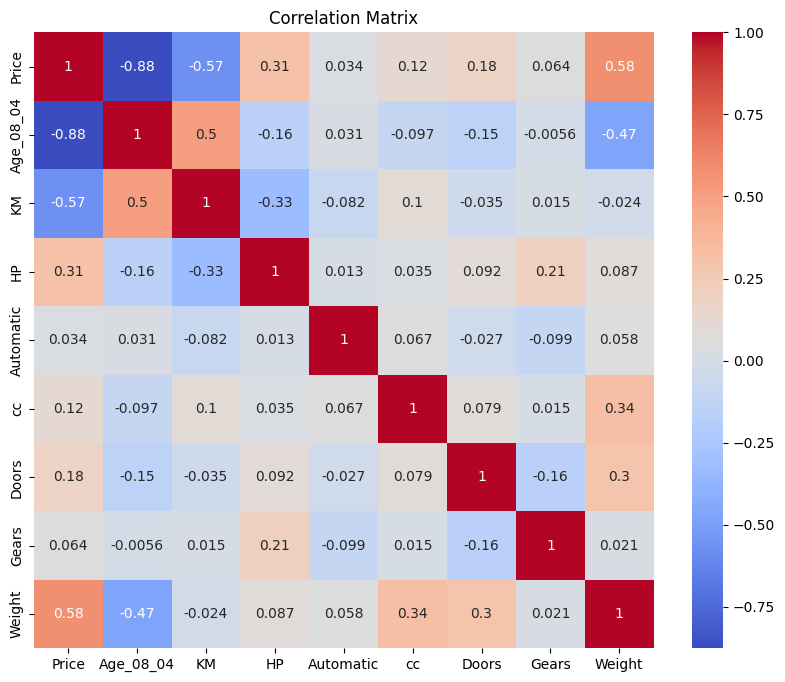

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

A correlation heatmap was used to examine relationships between variables.

Key insights:

Age has a strong negative correlation with Price

Weight has a strong positive correlation with Price

KM shows a negative correlation with Price, indicating that cars with higher mileage tend to have lower prices.

HP also shows a moderate positive correlation with Price.


##3.Boxplot for Outliers

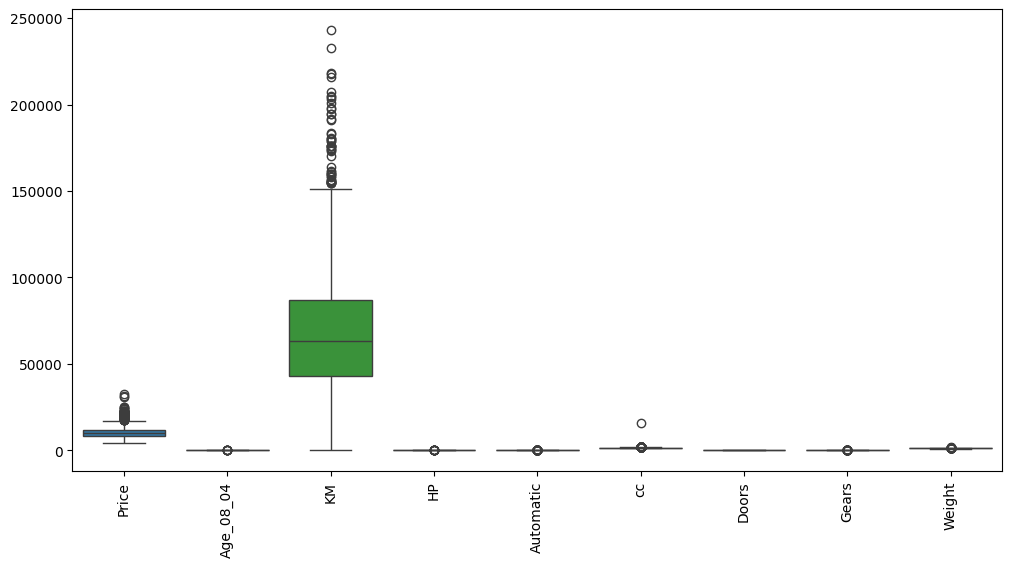

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
#sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Observation:

Outliers exist in:

Price

KM

cc

However they were retained because they represent valid extreme car specifications.

##Encoding Categorical Variables

Categorical variables must be converted into numerical form.

In [ ]:
df = pd.get_dummies(df, columns=['Fuel_Type','Doors'], drop_first=True)

In [ ]:
df

,Price,Age_08_04,KM,HP,Automatic,cc,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_3,Doors_4,Doors_5
0,13500,23,46986,90,0,2000,5,1165,True,False,True,False,False
1,13750,23,72937,90,0,2000,5,1165,True,False,True,False,False
2,13950,24,41711,90,0,2000,5,1165,True,False,True,False,False
3,14950,26,48000,90,0,2000,5,1165,True,False,True,False,False
4,13750,30,38500,90,0,2000,5,1170,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,5,1025,False,True,True,False,False
1432,10845,72,19000,86,0,1300,5,1015,False,True,True,False,False
1433,8500,71,17016,86,0,1300,5,1015,False,True,True,False,False
1434,7250,70,16916,86,0,1300,5,1015,False,True,True,False,False


The following encoding was applied:

•	Fuel_Type → One-hot encoding(3 unique values)

•	Doors → One-hot encoding(4 unique values)

Dummy variables were created using drop_first=True to avoid the dummy variable trap.

After encoding, the dataset contains 1435 rows and 13 columns.

The following code will convert True/False to 1/0


In [ ]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [ ]:
df.shape

(1435, 13)

In [ ]:
df

,Price,Age_08_04,KM,HP,Automatic,cc,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_3,Doors_4,Doors_5
0,13500,23,46986,90,0,2000,5,1165,1,0,1,0,0
1,13750,23,72937,90,0,2000,5,1165,1,0,1,0,0
2,13950,24,41711,90,0,2000,5,1165,1,0,1,0,0
3,14950,26,48000,90,0,2000,5,1165,1,0,1,0,0
4,13750,30,38500,90,0,2000,5,1170,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,5,1025,0,1,1,0,0
1432,10845,72,19000,86,0,1300,5,1015,0,1,1,0,0
1433,8500,71,17016,86,0,1300,5,1015,0,1,1,0,0
1434,7250,70,16916,86,0,1300,5,1015,0,1,1,0,0


#Define Features and Target

In [ ]:
X = df.drop(columns=['Price'])
y = df['Price']

In [ ]:
X,y

(      Age_08_04     KM   HP  Automatic    cc  Gears  Weight  Fuel_Type_Diesel  \
 0            23  46986   90          0  2000      5    1165                 1   
 1            23  72937   90          0  2000      5    1165                 1   
 2            24  41711   90          0  2000      5    1165                 1   
 3            26  48000   90          0  2000      5    1165                 1   
 4            30  38500   90          0  2000      5    1170                 1   
 ...         ...    ...  ...        ...   ...    ...     ...               ...   
 1431         69  20544   86          0  1300      5    1025                 0   
 1432         72  19000   86          0  1300      5    1015                 0   
 1433         71  17016   86          0  1300      5    1015                 0   
 1434         70  16916   86          0  1300      5    1015                 0   
 1435         76      1  110          0  1600      5    1114                 0   
 
       Fuel_Ty

#Train-Test Split

Dataset split:

80% training

20% testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 12), (287, 12), (1148,), (287,))

##Standardization

Standardization is required especially for regularization models.

Standardization transforms variables so that:

•	Mean = 0

•	Standard Deviation = 1

This is particularly important for regularization models such as Ridge and Lasso regression.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled, X_test_scaled

(array([[ 1.18675584,  1.0599467 ,  0.56762241, ..., -0.87375103,
         -0.33204134,  1.07041786],
        [ 0.33084524, -0.26270276, -1.02918509, ..., -0.87375103,
         -0.33204134,  1.07041786],
        [ 0.81229495,  0.55985032, -1.02918509, ..., -0.87375103,
         -0.33204134,  1.07041786],
        ...,
        [ 1.29374467,  0.06036274,  0.56762241, ..., -0.87375103,
          3.0116732 , -0.93421461],
        [ 0.49132847, -0.12148568,  0.56762241, ..., -0.87375103,
         -0.33204134,  1.07041786],
        [ 1.0262726 ,  1.06727887,  0.56762241, ..., -0.87375103,
         -0.33204134,  1.07041786]]),
 array([[ 0.170362  ,  0.29673921,  0.56762241, ...,  1.14449078,
         -0.33204134, -0.93421461],
        [ 0.33084524, -0.1170652 ,  0.56762241, ..., -0.87375103,
         -0.33204134,  1.07041786],
        [ 0.170362  ,  1.60885364, -1.96065613, ..., -0.87375103,
          3.0116732 , -0.93421461],
        ...,
        [ 0.86578936, -1.14401907, -1.02918509, ...,  

The output of StandardScaler is a NumPy array, so it is converted back to a DataFrame to preserve feature names for further analysis.

In [ ]:
# Convert scaled arrays to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Model 1 → All features

•  Model 2 → Remove high multicollinearity (VIF)

•  Model 3 → Remove insignificant variables (p-value)



##Multicollinearity Check (VIF)

In [ ]:
X_train_const = sm.add_constant(X_train_scaled_df)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(len(X_train_const.columns))
]

print(vif_data.sort_values(by='VIF', ascending=True))

             Feature         VIF
0              const    1.000000
6              Gears    1.104320
4          Automatic    1.125662
5                 cc    1.190202
1          Age_08_04    1.961715
2                 KM    2.043543
3                 HP    2.487596
7             Weight    4.139749
9   Fuel_Type_Petrol   10.311054
8   Fuel_Type_Diesel   12.024089
11           Doors_4   52.542152
10           Doors_3  142.129796
12           Doors_5  144.430967


Interpretation:

VIF	Meaning

<5	Good

5–10	Moderate

Greater than 10	High multicollinearity

Some dummy variables may still show high VIF due to correlation with other predictors in the dataset.

These variables are not removed at this stage and will be addressed in the subsequent model refinement steps.


##Feature Selection using F-Regression

In [ ]:
f_scores, p_values = f_regression(X_train_scaled_df, y_train)

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F_score": f_scores,
    "p_value": p_values.round(4)
})

feature_scores.sort_values("F_score", ascending=False)

,Feature,F_score,p_value
0,Age_08_04,3774.692856,0.0000
6,Weight,600.095339,0.0000
1,KM,571.982744,0.0000
2,HP,127.867807,0.0000
11,Doors_5,39.225701,0.0000
9,Doors_3,22.196168,0.0000
4,cc,17.479356,0.0000
10,Doors_4,5.785596,0.0163
5,Gears,3.786244,0.0519
3,Automatic,3.186613,0.0745


F-test scores provide an indication of feature relevance but final feature selection should be based on regression coefficients and p-values.


##Now the task is -

Build a multiple linear regression model using the training dataset.

Interpret the coefficients of the model.

 Build a minimum of 3 different models.

 Model 1 → All features

 Model 2 → Remove high multicollinearity (VIF)

 Model 3 → Remove insignificant variables (p-value)


##Model 1 – Linear Regression (All Features)

and Evaluation:

In [ ]:
lr1 = LinearRegression()

lr1.fit(X_train_scaled_df, y_train)

pred1 = lr1.predict(X_test_scaled_df)

In [ ]:
lr1.coef_

array([-2255.82239919,  -603.5522323 ,   209.84212622,    45.38103844,
         -22.72357496,    86.54284874,  1391.81058092,  -154.66093614,
         385.49483145,  -295.86174091,   -99.16661293,  -394.36259869])

In [ ]:
lr1.intercept_

np.float64(10727.046167247385)

In [ ]:
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
r21 = r2_score(y_test, pred1)
print("RMSE1:", rmse1)
print("R-squared1:", r21)

RMSE1: 1478.183354984284
R-squared1: 0.8178709954799961


Model 1

RMSE = 1478.18

This indicates that the predicted values from Model 1 differ from the actual values by approximately 1478 units on average.

R² = 0.8179

This means that 81.79% of the variation in the dependent variable is explained by the independent variables included in Model 1, while about 18.21% of the variation remains unexplained.

##Model 2 – Remove High VIF Features

Remove:

Remove only very high VIF features (>10).




In [ ]:
drop_columns = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
drop_columns

['Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Doors_3', 'Doors_4', 'Doors_5']

In [ ]:
X_train_m2 = X_train_scaled_df.drop(columns=drop_columns)
X_test_m2 = X_test_scaled_df.drop(columns=drop_columns)
lr2 = LinearRegression()
lr2.fit(X_train_m2, y_train)
pred2= lr2.predict(X_test_m2)

In [ ]:
lr2.coef_

array([-2272.22490455,  -738.94523227,   460.52044931,   115.67690076,
         -64.71267836,    81.94574472,  1008.46609904])

In [ ]:
lr2.intercept_

np.float64(10727.046167247385)

In [ ]:
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
r22 = r2_score(y_test, pred2)
print("RMSE2:", rmse2)
print("R-squared2:", r22)

RMSE2: 1386.6747120625298
R-squared2: 0.8397228209964336


Model 2

RMSE = 1386.67

The average prediction error of Model 2 is approximately 1387 units, which is lower than Model 1, indicating improved prediction accuracy.

R² = 0.8397

Model 2 explains 83.97 % of the variance in the dependent variable, which is higher than Model 1, meaning it captures slightly more variability in the data.

###Feature Selection Model (Using OLS Regression)

In Model 3, feature selection is performed by identifying statistically significant predictors using Ordinary Least Squares (OLS) regression from the statsmodels library.

OLS regression provides coefficient estimates, standard errors, t-statistics, and p-values for each predictor variable. The p-value indicates whether a predictor has a statistically significant relationship with the target variable (Price).

A significance level of α = 0.05 is used for hypothesis testing:

Null hypothesis (H₀): The predictor has no effect on the target variable (coefficient = 0).

Alternative hypothesis (H₁): The predictor has a significant effect on the target variable (coefficient ≠ 0).

If the p-value < 0.05, the null hypothesis is rejected and the variable is considered statistically significant.
If the p-value > 0.05, the variable is considered insignificant and may be removed from the model.

Before fitting the OLS model, the index of the target variable y_train is reset using:

y_train.reset_index(drop=True)

This step ensures that the indices of y_train align correctly with the feature matrix X_train_const, which includes the constant (intercept) term added using sm.add_constant(). Setting drop=True removes the previous index instead of adding it as a new column.

The OLS model is then fitted using the training dataset:

model = sm.OLS(y_train.reset_index(drop=True), X_train_const).fit()

After examining the regression summary, predictors with p-values greater than 0.05 are identified and removed from the feature set. A new Linear Regression model is then trained using only the statistically significant variables, resulting in a more parsimonious and interpretable model.

The OLS model is fitted using the scaled training features with an added intercept term.

In [ ]:
model = sm.OLS(y_train.reset_index(drop=True), X_train_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     641.1
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:03:09   Log-Likelihood:                -9865.6
No. Observations:                1148   AIC:                         1.976e+04
Df Residuals:                    1135   BIC:                         1.982e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.073e+04     38.767  

OLS Model Performance

R-squared = 0.871

This means that 87.1% of the variation in car price is explained by the independent variables in the model.

Adjusted R-squared = 0.870

After adjusting for the number of predictors, about 87% of the variability in price is explained, indicating a very strong model fit.

F-statistic = 641.1, Prob(F-statistic) = 0.00

Since the p-value of the F-test is less than 0.05, the overall regression model is statistically significant, meaning that the independent variables jointly have a significant effect on Price.

Using the OLS regression results, variables with p-values greater than 0.05 are removed, and a new Linear Regression Model (Model 3) is trained using only statistically significant predictors.

In [ ]:
p_values_sorted = model.pvalues.sort_values().round(4)

print(p_values_sorted)

const               0.0000
Age_08_04           0.0000
Weight              0.0000
KM                  0.0000
HP                  0.0006
Fuel_Type_Petrol    0.0020
Gears               0.0339
Fuel_Type_Diesel    0.2502
Automatic           0.2701
Doors_5             0.3975
Doors_3             0.5222
cc                  0.5912
Doors_4             0.7242
dtype: float64


## Model 3 – Remove Insignificant Variables

we are going to drop columns with p_value > 0.05

In [ ]:
drop_columns = p_values_sorted[p_values_sorted > 0.05].index.tolist()
drop_columns

['Fuel_Type_Diesel', 'Automatic', 'Doors_5', 'Doors_3', 'cc', 'Doors_4']

In [ ]:
# Remove insignificant variables
X_train_m3 = X_train_scaled_df.drop(columns=drop_columns)
X_test_m3 = X_test_scaled_df.drop(columns=drop_columns)

lr3 = LinearRegression()
lr3.fit(X_train_m3, y_train)

pred3 = lr3.predict(X_test_m3)

rmse3 = np.sqrt(mean_squared_error(y_test, pred3))
r23 = r2_score(y_test, pred3)

print("RMSE3:", rmse3)
print("R-squared3:", r23)

RMSE3: 1447.7319996498286
R-squared3: 0.8252976100228695


RMSE3 = 1447.73

The Root Mean Squared Error for Model 3 is 1447.73, which means that the predicted car prices differ from the actual prices by approximately 1448 units on average.

R-squared3 = 0.8253

The R² value of 0.8253 indicates that 82.53% of the variation in car price is explained by the independent variables included in Model 3, while about 17.47% of the variation remains unexplained.

| Model       | RMSE        | R²         | Interpretation                                                   |
| ----------- | ----------- | ---------- | ---------------------------------------------------------------- |
| **Model 1** | 1478.18     | 0.8179     | Baseline model with higher prediction error                      |
| **Model 2** | **1386.67** | **0.8397** | Best performance with lowest error and highest explanatory power |
| **Model 3** | 1447.73     | 0.8253     | Slightly worse than Model 2 but still better than Model 1        |

##Cross-Validation
Cross-validation ensures model stability.

In [ ]:
lr = LinearRegression()

# Cross-validated R²

cv_r2 = cross_val_score(lr, X_train_m2, y_train, cv=5, scoring='r2')

# Cross-validated RMSE

cv_rmse = np.sqrt(-cross_val_score(lr, X_train_m2, y_train,
                                   cv=5, scoring='neg_mean_squared_error'))

print("Cross-validation R2 scores:", cv_r2)
print("Average CV R2:", cv_r2.mean())

print("Cross-validation RMSE scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-validation R2 scores: [0.87078232 0.6517345  0.85672282 0.83434188 0.83226831]
Average CV R2: 0.8091699655246221
Cross-validation RMSE scores: [1322.53230408 2305.72944488 1334.89700318 1446.68684875 1417.46489467]
Average CV RMSE: 1565.4620991103388


A 5-fold cross-validation was conducted to evaluate the stability and generalization ability of the regression model. The dataset was divided into five subsets, where in each iteration the model was trained on four folds and validated on the remaining fold. This process was repeated five times so that each fold served once as the validation set.

The R² scores obtained across the folds were [0.8708, 0.6517, 0.8567, 0.8343, 0.8323], with an average cross-validated R² of 0.8092. This indicates that, on average, the model explains about 80.92% of the variance in the target variable across different data splits.

The RMSE values across the folds were [1322.53, 2305.73, 1334.90, 1446.69, 1417.46], with an average RMSE of 1565.46,meaning that the model’s predictions deviate from the actual values by approximately 1565 units on average across validation folds.

The cross-validation results indicate that the model explains about 81% of the variance in the target variable, which is reasonably consistent with the performance observed in the train–test evaluation. However, the variation in RMSE values across the folds suggests that prediction errors differ across subsets of the data. The average RMSE of approximately 1565.46 represents the expected prediction error on unseen data across different data splits.

Overall, cross-validation provides a more reliable estimate of the model’s generalization performance, and the analysis will now proceed with regularization techniques such as Ridge and Lasso regression to further improve model stability and predictive accuracy

##Ridge Regression

Ridge adds L2 regularization to reduce multicollinearity.

In [ ]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=5)

In [ ]:
#ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
print("Ridge R2:", ridge_r2)
print("Ridge RMSE:", ridge_rmse)

Ridge R2: 0.83123447668724
Ridge RMSE: 1422.92043321201


##Lasso Regression

Lasso adds L1 regularization and performs feature selection.

In [ ]:
lasso = Lasso(alpha=0.1, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
print("Lasso R2:", lasso_r2)
print("Lasso RMSE:", lasso_rmse)

Lasso R2: 0.8179212557919633
Lasso RMSE: 1477.9793812047953


##Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression (All Features)",
        "Linear Regression (Reduced)",
        "Linear Regression (Selected)",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R2 Score": [r21, r22, r23, ridge_r2, lasso_r2],
    "RMSE": [rmse1, rmse2, rmse3, ridge_rmse, lasso_rmse]
})

print(results)

                              Model  R2 Score         RMSE
0  Linear Regression (All Features)  0.817871  1478.183355
1       Linear Regression (Reduced)  0.839723  1386.674712
2      Linear Regression (Selected)  0.825298  1447.732000
3                  Ridge Regression  0.831234  1422.920433
4                  Lasso Regression  0.817921  1477.979381


#Conclusion

The aim of this project was to develop a Multiple Linear Regression model to predict the prices of Toyota Corolla cars using various vehicle characteristics.

Key findings:

Age, kilometers driven, horsepower, and weight were identified as important predictors of car price. The analysis shows that older cars and vehicles with higher mileage tend to have lower prices, indicating depreciation with usage. On the other hand, cars with greater horsepower and higher weight generally have higher prices, reflecting better performance and build quality.

Model performance:

The baseline Linear Regression model using all features achieved an R² of 0.8179 with an RMSE of 1478.18, indicating that the model explains a large portion of the variability in car prices.
After removing variables with high multicollinearity, Model 2 achieved the best performance with an R² of 0.8397 and RMSE of 1386.67, indicating improved predictive accuracy compared to the baseline model.

Regularization techniques were also applied. Ridge Regression produced an R² of 0.8182, while Lasso Regression achieved an R² of 0.8179. Although these methods did not outperform the reduced linear regression model, they help improve model robustness and address potential multicollinearity.

Overall, the regression models explain around 82% of the variation in Toyota Corolla prices, indicating strong predictive capability. Among the models tested, the Reduced Linear Regression model provides the best balance between accuracy and model simplicity for predicting car prices.


##Interview Questions

##1.What is Normalization & Standardization and how is it helpful?

Normalization and Standardization are data scaling techniques used in data preprocessing to bring features to a similar scale.

Normalization rescales the data to a fixed range, usually between 0 and 1, using the min–max scaling method.

(X_norm = X - X_min / X_max - X_min)

Standardization, on the other hand, transforms the data so that it has a mean of 0 and a standard deviation of 1, using the Z-score formula.

( Z = X - mue / sigma )

These techniques are helpful because they remove differences in feature scales, which improves the performance of machine learning algorithms, especially distance-based methods like KNN, K-means, Linear Regression, Logistic Regression, SVM, PCA and helps models converge faster during training.

##2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when two or more independent variables in a multiple linear regression model are highly correlated, making coefficient estimates unstable and difficult to interpret.

Techniques to Address Multicollinearity

Identify and Remove Highly Correlated Variables

Use a correlation matrix and heatmap to detect strongly correlated predictors. If two variables are highly correlated, remove one to reduce redundancy.

Variance Inflation Factor (VIF)

Calculate VIF to quantify multicollinearity. Variables with VIF > 5 or 10 indicate high multicollinearity and may be removed.

Combine Correlated Variables

Merge highly correlated predictors into a single feature (e.g., index or average).

Principal Component Analysis (PCA)

Transform correlated predictors into uncorrelated principal components and use them in the regression model.

Regularization Methods

Apply Ridge Regression or Lasso Regression, which penalize large coefficients and help reduce the impact of multicollinearity.

Multicollinearity can be handled by identifying correlated variables using correlation matrices or heatmaps, checking VIF, combining variables, applying PCA, or using regularization techniques like Ridge and Lasso regression.

